### Coding Attention Mechanisms

In [2]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [3]:
query = inputs[1]  # 2nd input token is the query

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [4]:
res = 0.

for idx, element in enumerate(inputs[0]):
    res += inputs[0][idx] * query[idx]

print(res)
print(torch.dot(inputs[0], query))

tensor(0.9544)
tensor(0.9544)


In [5]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.)


### Self-Attention with Trainable Weights

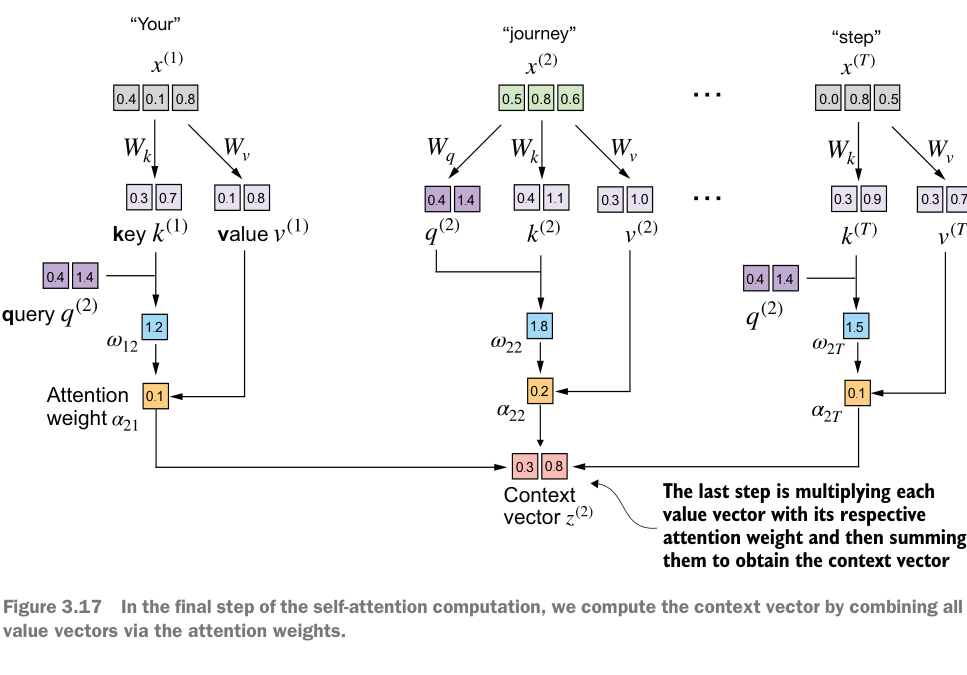

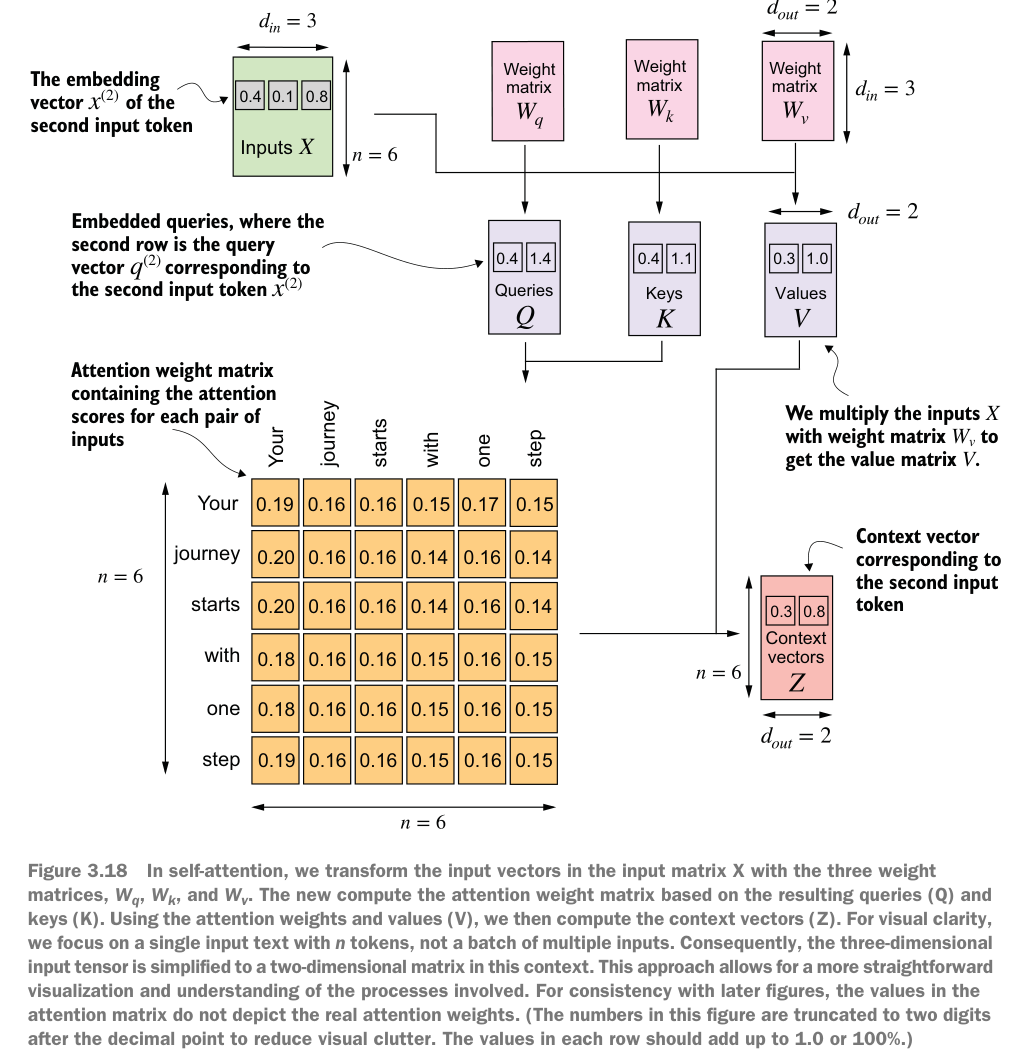

In [6]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.randn(d_in, d_out))
        self.W_key = nn.Parameter(torch.randn(d_in, d_out))
        self.W_value = nn.Parameter(torch.randn(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value

        # Compute attention scores
        attn_scores = queries @ keys.T

        # Compute attention weights
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        # Compute context
        context_vec = attn_weights @ values
        return context_vec

In [7]:
x_2 = inputs[1]  # 2nd input token is the query
d_in = inputs.shape[1] # the input embedding size, d=3
d_out = 2 # the output embedding size, d=2

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print("sa_v1(inputs):\n", sa_v1(inputs))

sa_v1(inputs):
 tensor([[0.2845, 0.4071],
        [0.2854, 0.4081],
        [0.2854, 0.4075],
        [0.2864, 0.3974],
        [0.2863, 0.3910],
        [0.2860, 0.4039]], grad_fn=<MmBackward0>)


In [8]:
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()

        # Using Linear over Parameter (i.e in sa_v1)
        # since Linear has a preferred weight init scheme,
        # leads to more stable training.
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


### Causal Attention
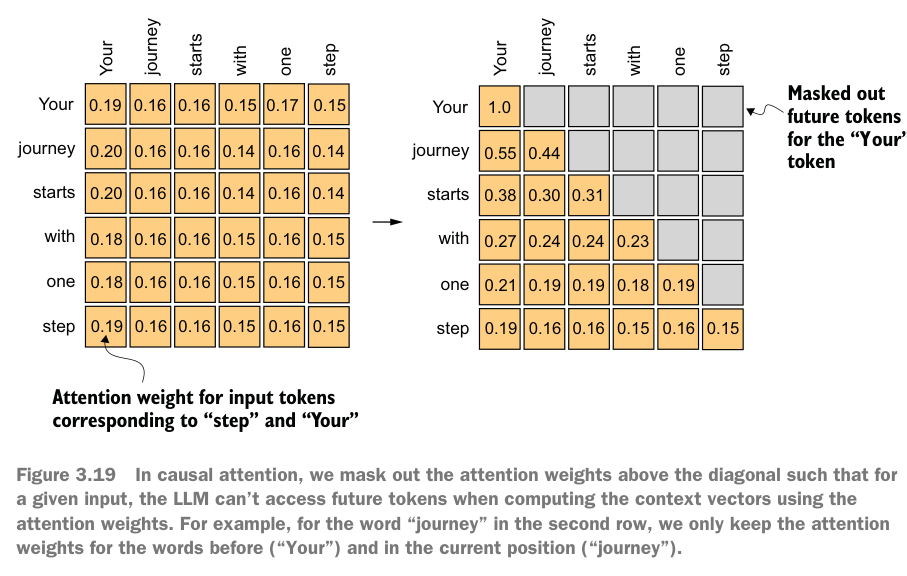

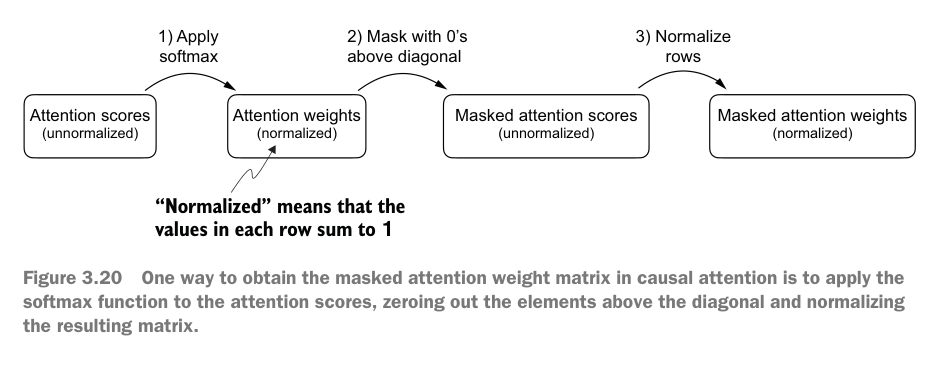

In [9]:
# Reuse the query and key weight matrices of the
# SelfAttention_v2 object from the previous section for convenience
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

print(f"attn_weights.shape: {attn_weights.shape}")

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)
attn_weights.shape: torch.Size([6, 6])


In [10]:
# Creating a causal mask to prevent attending to future tokens
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

# Applying mask to the attention weights
# NOTE: This doesn't some to 1!
masked_simple = attn_weights*mask_simple
print("Attention weight causal masked:\n", masked_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])
Attention weight causal masked:
 tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


This simple mask will create issues however:
- If mask applied after softmax, would disrupt prob distribution
- Softmax ensures all output values sum to 1
- Masking after softmax would require re-norm, which complicates process and might lead to unintended effects.

In [11]:
# Re-norm so they sum to one
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print("Attention weight causal masked and normalized:\n", masked_simple_norm)

Attention weight causal masked and normalized:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


More efficient way of computing masked attention weights:
- softmax function treats -inf as 0 (i.e exp(-inf) = 0)

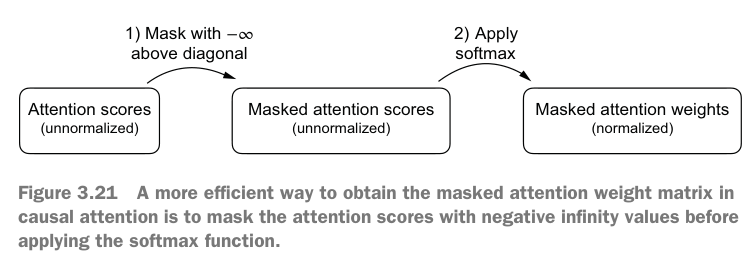

In [12]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1).bool()
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)

print(f"mask:\n{mask}")
print(f"masked:\n{masked}")
print("-------------------")

# Applying normalization after masking
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print("Attention weights after masking and normalization:\n", attn_weights)

mask:
tensor([[False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False]])
masked:
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)
-------------------
Attention weights after masking and normalization:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319,

#### Masking additional attention weights with dropout
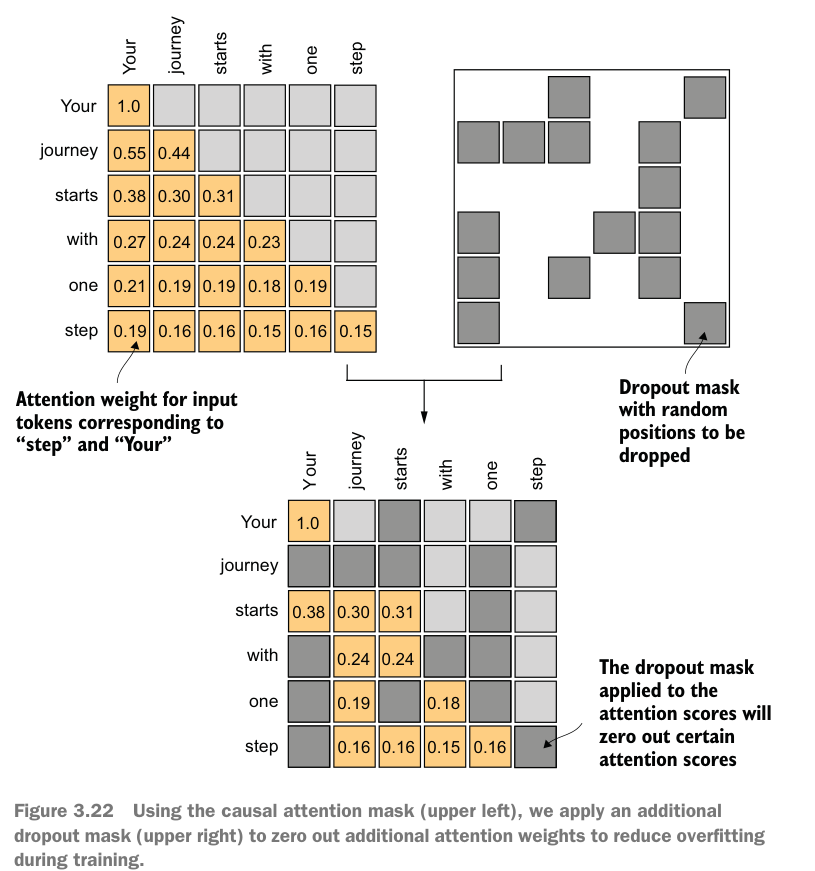

In [13]:
# Dropout tests
torch.manual_seed(123)
dropout = torch.nn.Dropout(p=0.5)

example = torch.ones(6,6)
dropped = dropout(example)
print("Original:\n", example)
print("After Dropout:\n", dropped)

Original:
 tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
After Dropout:
 tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


Note that when applying dropout to attention weight matrix with 50%, half of elements are randomly set to zero.
- To compensate for reduction, active elements in matrix are scaled by 1 / 0.5 = 2
- Scaling crucial for ensuring average influence of attention mechanism remains consistent during training/inference

In [14]:
# Apply dropout to the attention weights
torch.manual_seed(123)
dropout = torch.nn.Dropout(p=0.5)
print("Attention weights before dropout:\n", attn_weights)
attn_weights_dropped = dropout(attn_weights)
print("Attention weights after dropout:\n", attn_weights_dropped)

Attention weights before dropout:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)
Attention weights after dropout:
 tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


### Causal Attention Class

In [15]:
# Setting up batch inputs
batch = torch.stack([inputs, inputs], dim=0) 
print("Batch shape:", batch.shape)  # Should be (batch_size, seq_length, embedding_dim)

Batch shape: torch.Size([2, 6, 3])


In [16]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # (batch_size, seq_length, embedding_dim)
        keys = self.W_key(x)             # (batch_size, seq_length, d_out)
        queries = self.W_query(x)        # (batch_size, seq_length, d_out)
        values = self.W_value(x)         # (batch_size, seq_length, d_out)

        # Compute attention scores
        attn_scores = queries @ keys.transpose(1, 2)  # (batch_size, seq_length, seq_length)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)

        # Compute attention weights with softmax
        attn_weights = torch.softmax(attn_scores / self.d_out**0.5, dim=-1)

        # Apply dropout to the attention weights
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values  # (batch_size, seq_length, d_out)
        return context_vec


In [17]:
# Testing
torch.manual_seed(123)
context_length = batch.shape[1]  # seq_length
ca = CausalAttention(d_in, d_out, context_length, dropout=0.0)

context_vecs = ca(batch)
print("Context vectors shape:", context_vecs.shape)  # Should be (batch_size,

Context vectors shape: torch.Size([2, 6, 2])


### Multihead Attention
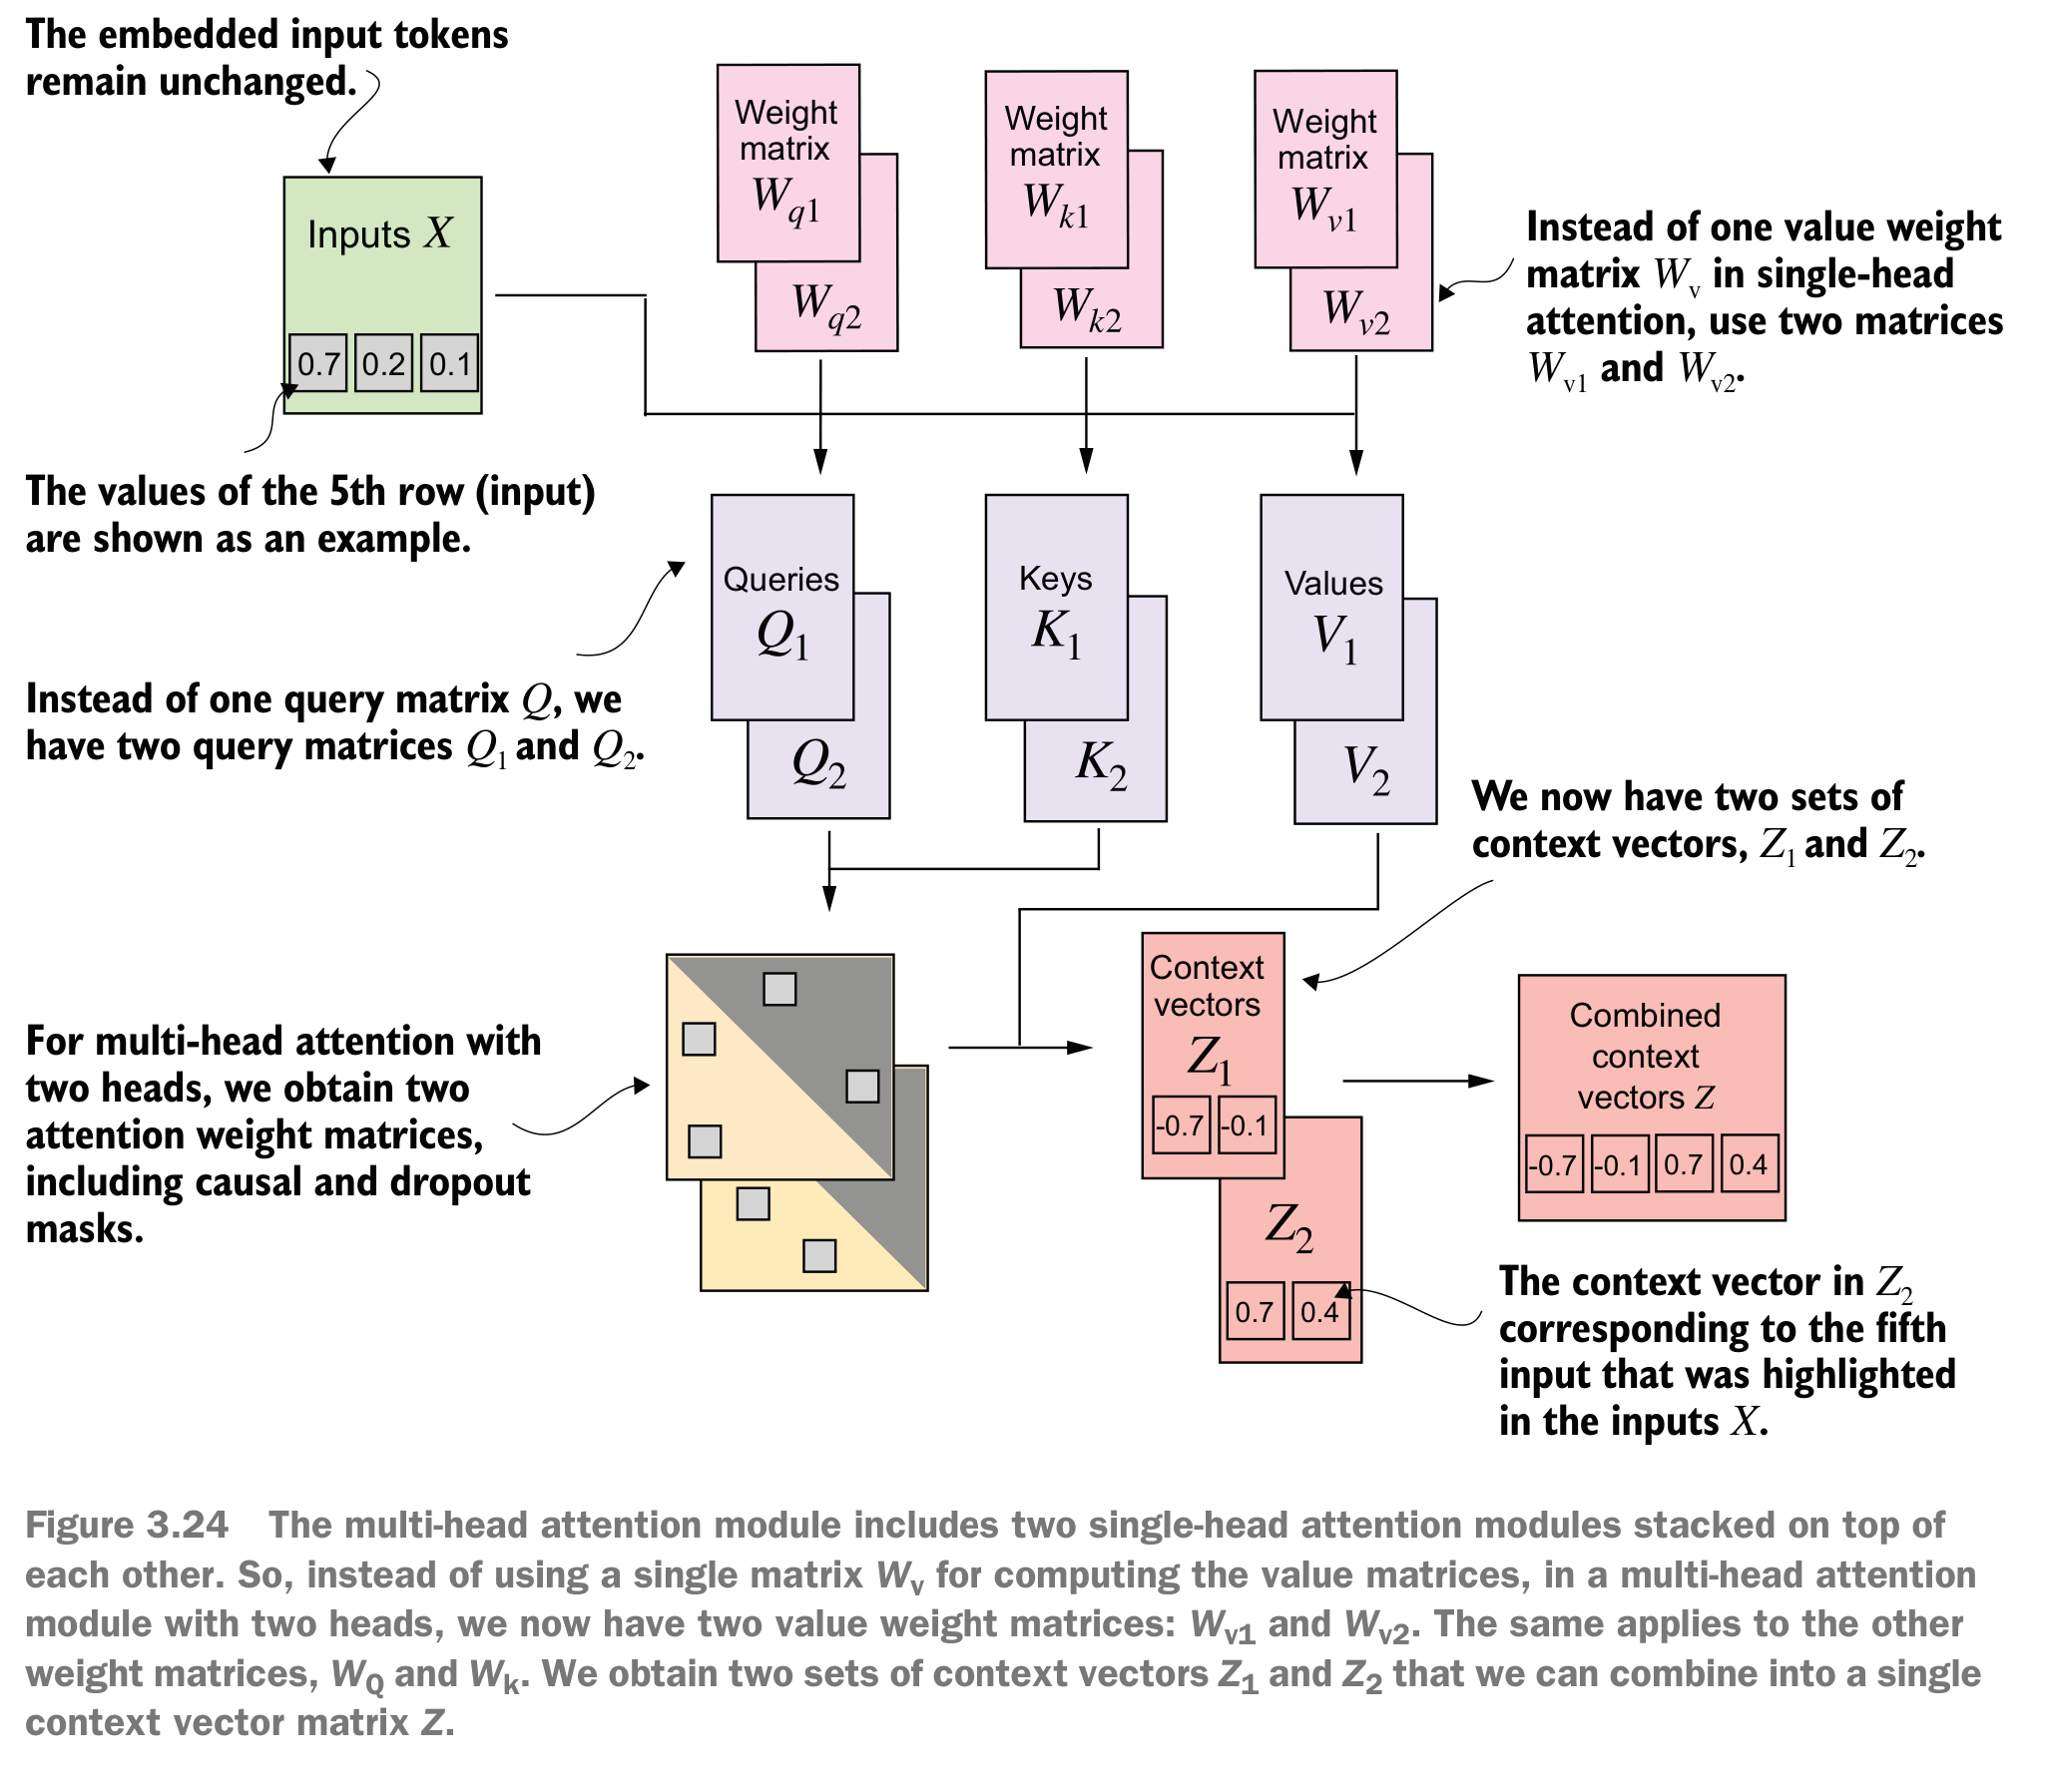

In [18]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.heads = nn.ModuleList([
            CausalAttention(
                d_in, d_out, context_length, dropout, qkv_bias=qkv_bias) 
                for _ in range(num_heads)
        ])

    def forward(self, x):
        # NOTE: Can improve this by splitting heads in parallel
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [19]:
torch.manual_seed(123)
context_length = batch.shape[1]  # seq_length
d_in = 3
d_out = 3

mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout=0.0, num_heads=1)
context_vecs = mha(batch)
print(f"batch shape: {batch.shape}")
print("Context vectors shape:", context_vecs.shape)  # Should be (batch, seq_length, d_out*num_heads)

print("\n----------\n")
mha2 = MultiHeadAttentionWrapper(d_in, 1, context_length, dropout=0.0, num_heads=2)
context_vecs2 = mha2(batch)
print(f"batch shape: {batch.shape}")
print("Context vectors 2 shape:", context_vecs2.shape)  # Should be (batch, seq_length, d_out)



batch shape: torch.Size([2, 6, 3])
Context vectors shape: torch.Size([2, 6, 3])

----------

batch shape: torch.Size([2, 6, 3])
Context vectors 2 shape: torch.Size([2, 6, 2])


Embedding dim (d_out)
Final embedding dim will be (d_out * num_heads)
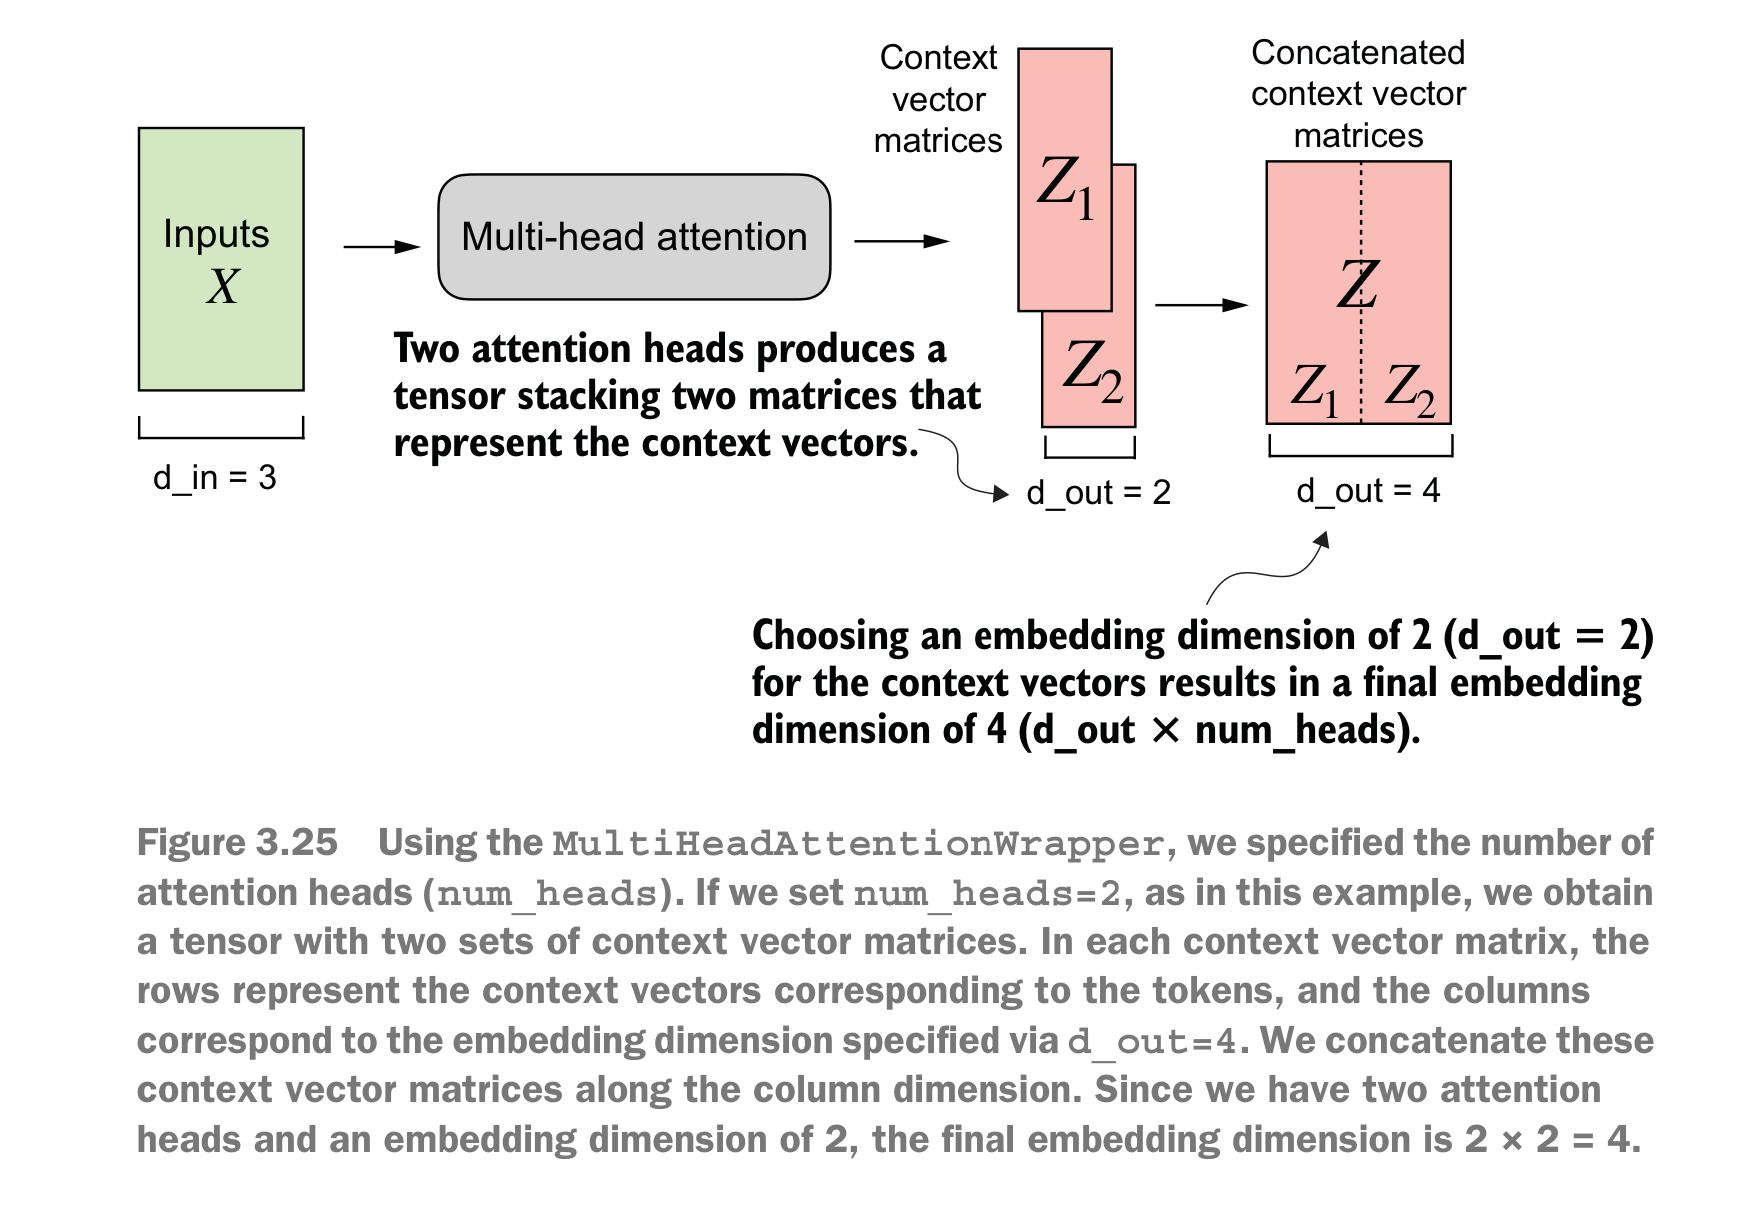

##### Multihead Attention Improvement

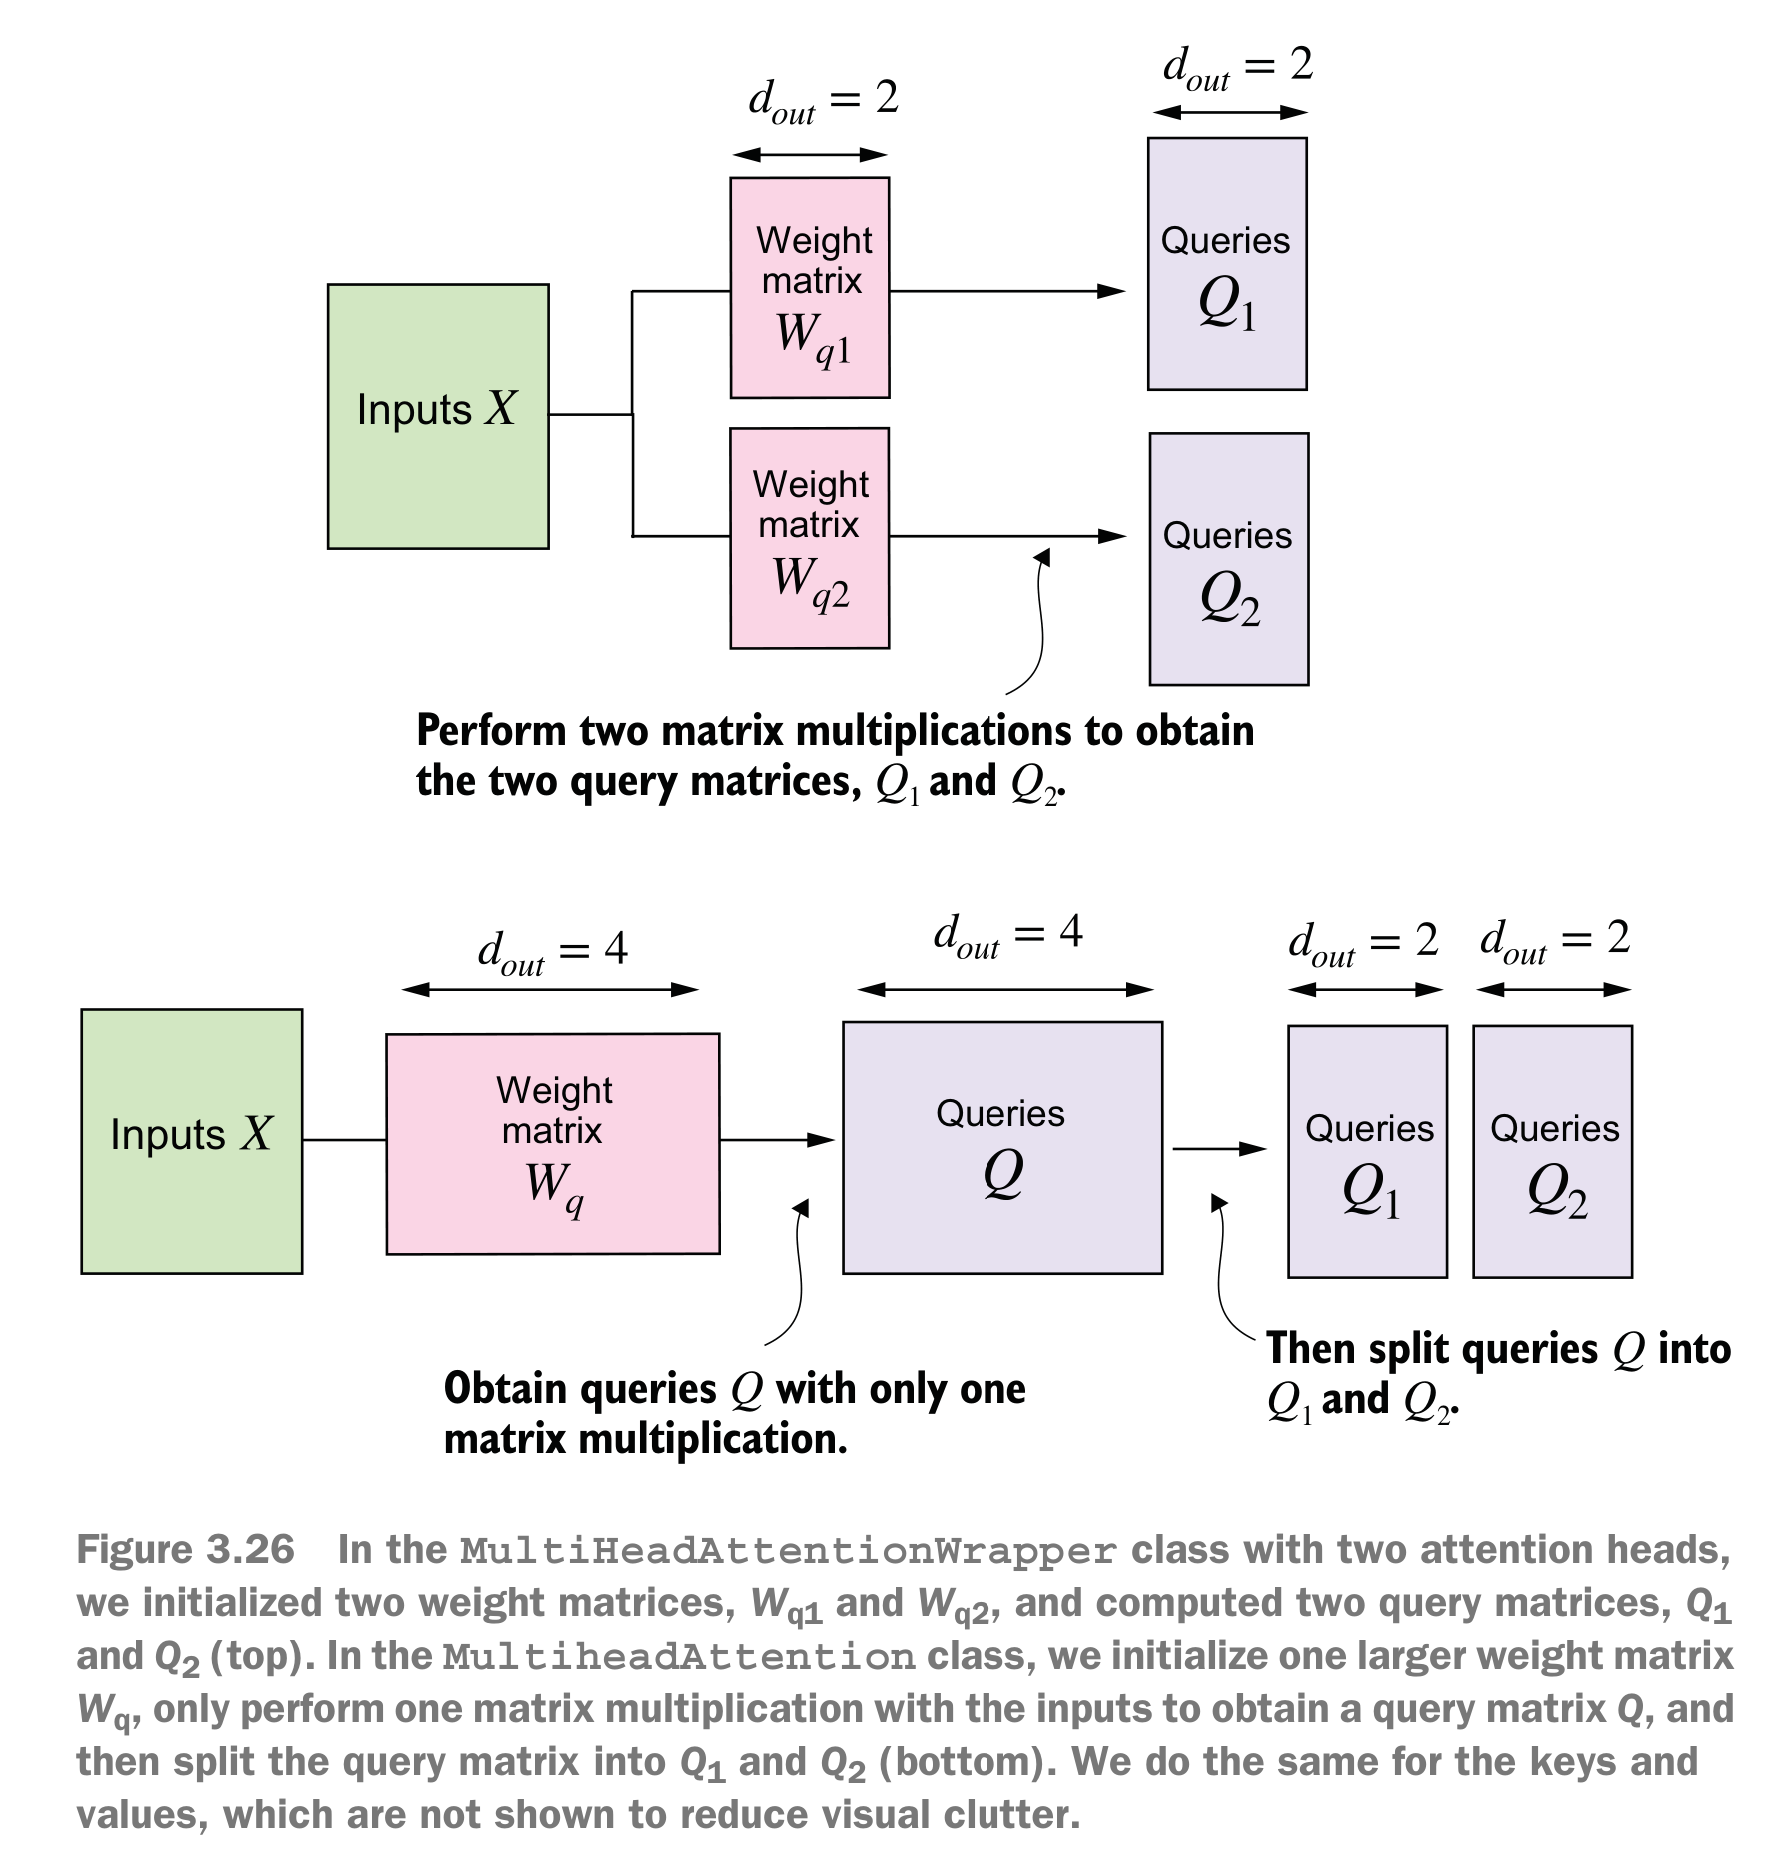

In [27]:
# (b, num_heads, num_tokens, head_dim) = (1, 2, 3, 4)
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388],
                    [0.7179, 0.7058, 0.9156, 0.4340]],

                   [[0.0772, 0.3565, 0.1479, 0.5331],
                    [0.4066, 0.2318, 0.4545, 0.9737],
                    [0.4606, 0.5159, 0.4220, 0.5786]]]])

# (b, num_heads, num_tokens, head_dim) * (b, num_heads, head_dim, num_tokens)
# (1, 2, 3, 4) @ (1, 2, 4, 3) = (1, 2, 3, 3)
result = a @ a.transpose(2, 3)      
print(result.shape)  # Should be (1, 2, 3, 3)
print(result)

# -- Head analysis
print("\n----------\n")
first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)

second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)

torch.Size([1, 2, 3, 3])
tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])

----------

First head:
 tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])

Second head:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


In [21]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce proj. dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)  # Linear lay layer to combine heads
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape   # (batch_size, seq_length, embedding_dim)

        keys = self.W_key(x)             # (batch_size, seq_length, d_out)
        queries = self.W_query(x)        # (batch_size, seq_length, d_out)
        values = self.W_value(x)         # (batch_size, seq_length, d_out)

        # Implicitly split matrix by adding num_heads dimension
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute dot product for each attention head
        attn_scores = queries @ keys.transpose(2, 3)

        # Mask truncated to number of tokens..?
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)   # (b, num_tokens, num_heads, head_dim)

        # Combine heads, self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec


In [25]:
torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)    # (batch_size, seq_length, d_out)
print("batch.shape:", batch.shape)
print("context_length:", context_length)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])
batch.shape: torch.Size([2, 6, 3])
context_length: 6


Note that d_out actually outputs d_out in Multihead Attention efficient implementation to make it more user friendly.
In MultiHeadAttentionWrapper, due to cocatenation outputs d_out * num_heads.